In [36]:
import json
import random
import os
import copy
import torch
import pickle

import torch.nn.functional as F

from tqdm import tqdm
from datasets import load_from_disk
from sentence_transformers import SentenceTransformer
from utils.flat import get_tag_map, get_entity_type_desc
from collections import defaultdict
from seqeval.metrics.sequence_labeling import get_entities

In [37]:
from datasets import load_from_disk

ds = load_from_disk("/kaggle/working/ToNER/data/my_data")

In [38]:
from seqeval.metrics.sequence_labeling import get_entities

In [39]:
data_type = 'my_data' # dataset name

recall_model = SentenceTransformer(
    "/kaggle/input/models/hinoeiji/toner-typematcher/transformers/bge-m3/1/tmp_bge_m3",
    device="cuda"
)

In [93]:
def get_score(model, input, keys, topk=5):
    # key ở đây là entity descript đã cộng tên vào
    # input là đoạn text
    embedding = model.encode([input] + keys, convert_to_tensor=True, normalize_embeddings=True)
    input_embedding = embedding[0]
    keys_embedding = embedding[1:]
    similarities = F.cosine_similarity(
        input_embedding.unsqueeze(0),
        keys_embedding
    )
    topk_scores, topk_indices = torch.topk(similarities, topk)
    return (topk_scores , [keys[topk_indices[i]].split(": ")[0] for i in range(len(topk_indices))])

def get_group_item(model, ds, idx, schemas):
    # trả về dict:
    # {
    #     "pos": [score],
    #     "neg": [score]
    # }

    text = " ".join(ds[idx]['tokens'])
    tags = [get_tag_map("my_data")[x] for x in ds[idx]['tags'] if x != 0]
    gt = list(set([tag.split("-")[1].lower() for tag in tags]))
    # print(gt)
    # tạo keys
    keys = [x + ": " + get_entity_type_desc("my_data")[x] for x in schemas]

    scores, topk_keys = get_score(model, text, keys, topk=len(keys))

    pos = []
    neg = []
    for i in range(len(topk_keys)):
        if topk_keys[i] in gt:
            pos.append(scores[i].item())
        else:
            neg.append(scores[i].item())

    return {
        "pos": pos,
        "neg": neg
    }



In [66]:
get_tag_map("my_data")

{0: 'O',
 1: 'B-PRODUCT',
 2: 'I-PRODUCT',
 3: 'B-GENERAL',
 4: 'I-GENERAL',
 5: 'B-SERVICE',
 6: 'I-SERVICE',
 7: 'B-PRODUCT FEATURE',
 8: 'I-PRODUCT FEATURE',
 9: 'B-PRODUCT USAGE',
 10: 'I-PRODUCT USAGE',
 11: 'B-PRODUCT DESIGN',
 12: 'I-PRODUCT DESIGN',
 13: 'B-PRODUCT QUALITY',
 14: 'I-PRODUCT QUALITY',
 15: 'B-PRICE',
 16: 'I-PRICE',
 17: 'B-DELIVERY',
 18: 'I-DELIVERY'}

In [50]:
schemas = list(get_entity_type_desc("my_data").keys())

In [55]:
get_entity_type_desc("my_data")

{'general': 'Những câu thuộc chủ đề chung chung, chứa các aspect ngầm',
 'product': 'Những câu thuộc chủ đề liên quan đến sản phẩm nói chung nhưng không rõ ràng về phía cạnh nào',
 'service': 'Những câu có chủ đề liên quan tới dịch vụ nói chung , thái độ của nhân viên , các chương trình đặc biệt',
 'delivery': 'Những câu có liên quan đến giao hàng , đóng gói , vận chuyển',
 'price': 'Những câu có liên quan đến giá cả của sản phẩm',
 'product feature': 'Những câu nói về những đặc trưng tự nhiên , đặc điểm vốn có của sản phẩm',
 'product usage': 'Những câu nói về công dụng của sản phẩm , cảm nhận trong quá trình sử dụng sản phẩm',
 'product design': 'Những câu liên quan đến bao bì , màu săc , thiết kế của sản phẩm',
 'product quality': 'Những câu liên quan đến chất lượng của sản phẩm , độ bền , độ hoàn thiện của sản phẩm'}

In [94]:
data = {
    "pos": [],
    "neg": []
}
for i in range(len(dev_set)):
    sample = get_group_item(recall_model, dev_set, i, schemas)
    data["pos"].extend(sample["pos"])
    data["neg"].extend(sample["neg"])

In [91]:
len(dev_set)

927

In [97]:
len(data['pos'])

2268

In [100]:
6075**0.5

77.94228634059948

In [98]:
len(data['neg'])

6075

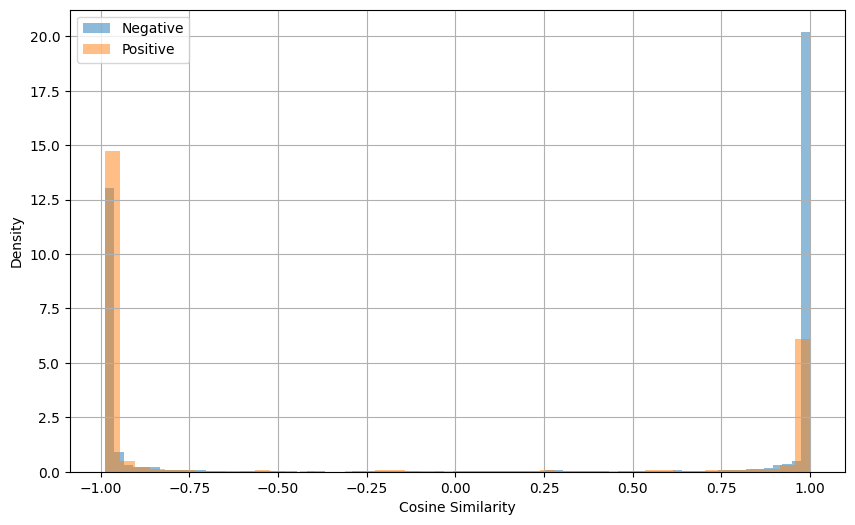

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    data["neg"],
    bins=77,
    density=True,
    alpha=0.5,
    label="Negative"
)

plt.hist(
    data["pos"],
    bins=47,
    density=True,
    alpha=0.5,
    label="Positive"
)

plt.xlabel("Cosine Similarity")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()